# GC-LoRA: Adaptive Expert Flywheel for Online Representation Adaptation

## Goal

This notebook implements a research proof-of-concept for **continuous online adaptation in LLMs** using a frozen backbone and a population of competing, parameter-efficient LoRA experts.

A frozen LLM can be augmented with a population of small, parallel LoRA experts whose usefulness is tracked online. Useful experts survive and propagate; harmful, redundant, or drifting experts are removed by a garbage-collection mechanism.

This creates an **adaptive expert flywheel**:

```text
interaction stream
      ↓
frozen backbone representation
      ↓
parallel LoRA expert branches
      ↓
gain-weighted mixture
      ↓
self-supervised loss and local fitness signals
      ↓
EMA gain update
      ↓
kill / clone / perturb garbage collection
      ↓
updated expert population
      ↓
next interaction
```

## Why this matters

Modern LLMs are mostly static after deployment. New knowledge is usually added by:

- full retraining,
- offline fine-tuning,
- retrieval-augmented generation,
- manually curated memory.

These methods either avoid modifying the model or require offline optimization.

The unresolved research problem is the **stability–plasticity dilemma**:

How can a system acquire useful new representations without destroying previously useful ones?

This notebook explores a deliberately modular answer:

- the backbone remains frozen as the stable slow system;
- adaptation happens only in small LoRA expert branches;
- experts compete in parallel;
- expert usefulness is measured continuously;
- bad experts are removed instead of endlessly repaired;
- good experts are cloned and perturbed.

## Important design constraint


This preserves the intended mechanism: **simultaneous expert competition inside a single forward pass**.

## This notebook demonstrates


1. whether expert gains separate across domains;
2. whether noisy or harmful experts lose fitness;
3. whether old-domain validation degrades less than in a single-adapter baseline;
4. whether birth/death dynamics remain observable and stable;
5. whether the system can run in a persistent online interaction loop with three modes:
   - `inference_only`,
   - `learn_from_input`,
   - `quarantine_input`.

## Research status

This is a proof-of-concept, not a solved continual-learning system.

A successful run would not prove general continual learning.  
It would demonstrate that **parallel LoRA expert populations with gain-controlled garbage collection** are a plausible experimental mechanism for online representation adaptation.

# Literature Mapping

Each major component in the notebook is intentionally tied to an existing research concept.

| Notebook component | Related literature / concept | Role in this experiment |
|---|---|---|
| Frozen Qwen2.5-0.5B backbone | Complementary Learning Systems; slow cortical system | Stable representation substrate |
| LoRA experts | Low-Rank Adaptation | Cheap local adaptation without updating full model |
| Parallel expert branches | Mixture of Experts | Multiple competing transformations of the same hidden state |
| Gain-based weighting | Hedge / multiplicative weights | Online reweighting of competing hypotheses |
| EMA fitness | Adam first-moment estimate | Smooth noisy per-batch fitness signals |
| Survival threshold | Adaptive Resonance Theory vigilance | Reject unstable or insufficiently useful representations |
| Clone + perturb | Population Based Training; NEAT-style mutation | Exploit good experts and explore nearby variants |
| Expert garbage collection | Stability–plasticity / pruning analogy | Remove harmful or redundant adaptation modules |
| Online flywheel | Data flywheel / MAPE loop analogy | Continuous monitor–adapt–evaluate cycle |

The point is not that GC-LoRA is identical to any one of these methods.  
The point is that every design parameter is anchored to a known family of mechanisms rather than introduced as an arbitrary engineering constant.

# 1. Environment Setup

This cell installs the minimum packages required to run the notebook on a Colab/Kaggle-style T4 GPU.

The implementation uses Hugging Face Transformers for Qwen2.5-0.5B, but does **not** rely on PEFT's multi-adapter switching because we need parallel LoRA branches inside the same forward pass.

The custom `ParallelLoRALinear` module below patches selected linear projections directly.

In [1]:
# Install only if needed. In many hosted notebooks these are already available.
# For a clean Colab runtime, uncomment the next line.

# !pip install -q "transformers>=4.45.0" "accelerate>=0.34.0" "datasets>=2.20.0" "matplotlib>=3.7.0" "pandas>=2.0.0" "sentencepiece" "einops"

import os
import math
import random
import copy
import json
import time
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any

import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

# 2. CONFIG

This is the central configuration cell.

Each parameter is grouped by function and commented with its research role.

The aim is to make the experiment reproducible and interpretable. If the experiment fails, the config should make it clear whether the failure is likely due to:

- expert capacity,
- gain dynamics,
- garbage-collection aggressiveness,
- data-stream design,
- validation design,
- or runtime constraints.

The default settings are conservative for a T4 GPU.

In [2]:
CONFIG = {
    # ----------------------------
    # Backbone: stable slow system
    # ----------------------------
    "model_name": "Qwen/Qwen2.5-0.5B",
    "freeze_backbone": True,

    # T4-safe setting:
    # The frozen backbone runs in fp16, but trainable LoRA expert parameters stay in fp32.
    # This avoids AdamW updating fp16 parameters, which is a common source of NaNs.
    "torch_dtype": "float16",
    "lora_param_dtype": "float32",
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # --------------------------------------------
    # Parallel LoRA expert injection configuration
    # --------------------------------------------
    "expert_mode": "parallel",
    "allow_sequential_eval": False,
    "target_module_names": ["down_proj"],
    "num_patched_layers": 4,

    # -------------------
    # LoRA expert capacity
    # -------------------
    "num_experts": 8,
    "lora_rank": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,

    # -----------------------------
    # Gain / online fitness tracking
    # -----------------------------
    "initial_gain": 1.0,
    "gain_ema_beta": 0.90,
    "hedge_eta": 0.30,
    "gain_min": -5.0,
    "gain_max": 5.0,

    # --------------------
    # Fitness composition
    # --------------------
    # Exact per-expert CE loss would require counterfactual separate forwards.
    # This notebook avoids that and uses signals available from one simultaneous pass.
    "fitness_alignment_weight": 1.00,
    "fitness_usage_weight": 0.10,
    "fitness_diversity_weight": 0.05,
    "fitness_drift_penalty_weight": 0.05,
    "fitness_loss_penalty_weight": 0.10,

    # -------------------------------
    # Garbage collector / expert birth
    # -------------------------------
    "gc_interval_batches": 100,
    "min_lifetime_gc_cycles": 2,
    "death_quantile": 0.20,
    "clone_source_quantile": 0.20,
    "mutation_sigma": 0.005,
    "vigilance_threshold": 0.70,

    # ----------------------
    # Optimizer and training
    # ----------------------
    # Lowered for T4 fp16-backbone / fp32-LoRA stability.
    "learning_rate": 5e-5,
    "weight_decay": 0.0,
    "adam_eps": 1e-6,
    "max_grad_norm": 0.5,
    "train_steps": 500,
    "batch_size": 2,
    "max_length": 192,
    "eval_every_batches": 50,

    # -----------------
    # Controlled stream
    # -----------------
    "domains": ["python", "math", "technical_qa", "noise"],
    "domain_schedule": ["python"] * 80 + ["math"] * 80 + ["technical_qa"] * 80 + ["noise"] * 40,

    # ----------------------
    # NaN / inf safety checks
    # ----------------------
    "skip_nonfinite_update": True,
    "reset_nonfinite_gain": True,
    "debug_numerics": True,

    # ---------------
    # Reproducibility
    # ---------------
    "seed": 42,
    "log_every": 10,
}

# 3. Literature References Used for Parameter Choices

This cell records the bibliographic anchors used by the config.

It is intentionally stored as data so that exported logs and future reports can preserve the mapping from design choice to literature family.

In [3]:
LITERATURE_MAP = {
    "LoRA experts": "Hu et al. (2021), Low-Rank Adaptation of Large Language Models",
    "Frozen slow system": "McClelland, McNaughton & O'Reilly (1995), Complementary Learning Systems",
    "Gain EMA": "Kingma & Ba (2015), Adam; Freund & Schapire (1997), Hedge / multiplicative weights",
    "Expert population": "Jaderberg et al. (2017), Population Based Training",
    "Kill/clone/perturb": "Stanley & Miikkulainen (2002), NEAT; PBT exploit-explore",
    "Vigilance threshold": "Grossberg / Carpenter, Adaptive Resonance Theory",
    "MoE comparison": "Shazeer et al. (2017); Fedus et al. (2022), Switch Transformer",
    "Adaptive flywheel": "Data flywheel / MAPE-style continuous improvement loops",
}

for k, v in LITERATURE_MAP.items():
    print(f"{k:24s} -> {v}")

LoRA experts             -> Hu et al. (2021), Low-Rank Adaptation of Large Language Models
Frozen slow system       -> McClelland, McNaughton & O'Reilly (1995), Complementary Learning Systems
Gain EMA                 -> Kingma & Ba (2015), Adam; Freund & Schapire (1997), Hedge / multiplicative weights
Expert population        -> Jaderberg et al. (2017), Population Based Training
Kill/clone/perturb       -> Stanley & Miikkulainen (2002), NEAT; PBT exploit-explore
Vigilance threshold      -> Grossberg / Carpenter, Adaptive Resonance Theory
MoE comparison           -> Shazeer et al. (2017); Fedus et al. (2022), Switch Transformer
Adaptive flywheel        -> Data flywheel / MAPE-style continuous improvement loops


# 4. Reproducibility and Device Utilities

This cell fixes random seeds and selects the compute device.

For a T4 GPU, `float16` is the safest default. The backbone remains frozen, so memory is mostly consumed by activations and the parallel LoRA branches.

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

device = torch.device(CONFIG["device"])
dtype_map = {
    "float16": torch.float16,
    "bfloat16": torch.bfloat16,
    "float32": torch.float32,
}
model_dtype = dtype_map[CONFIG["torch_dtype"]]
lora_param_dtype = dtype_map[CONFIG["lora_param_dtype"]]

print("Device:", device)
print("Backbone dtype:", model_dtype)
print("LoRA parameter dtype:", lora_param_dtype)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
Backbone dtype: torch.float16
LoRA parameter dtype: torch.float32
GPU: Tesla T4


# 5. Load Frozen Qwen2.5-0.5B

This cell loads the base model and freezes it.

The frozen model acts as the stable slow system. All online adaptation will be restricted to the LoRA expert branches introduced later.

This separation is central to the experiment:

```text
stable backbone = slow system
LoRA expert population = fast adaptive system
```

In [5]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"], trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_name"],
    torch_dtype=model_dtype,
    device_map=None,
    trust_remote_code=True,
).to(device)

if CONFIG["freeze_backbone"]:
    for p in model.parameters():
        p.requires_grad_(False)

model.config.use_cache = False
print("Loaded:", CONFIG["model_name"])
print("Total parameters:", sum(p.numel() for p in model.parameters()))
print("Trainable before patching:", sum(p.numel() for p in model.parameters() if p.requires_grad))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-0.5B
Total parameters: 494032768
Trainable before patching: 0


# 6. Expert State

This cell defines the global expert state.

The state is separate from the model parameters. It tracks:

- current gain per expert,
- age in garbage-collection cycles,
- number of deaths/rebirths,
- usage statistics,
- lifecycle events.

The separation is intentional: the expert parameters live inside LoRA modules, while expert-level evolutionary dynamics live in `ExpertState`.

In [6]:
@dataclass
class ExpertState:
    num_experts: int
    initial_gain: float = 1.0
    device: torch.device = torch.device("cpu")
    gain: torch.Tensor = field(init=False)
    age_gc_cycles: torch.Tensor = field(init=False)
    birth_count: torch.Tensor = field(init=False)
    death_count: torch.Tensor = field(init=False)
    last_reward: torch.Tensor = field(init=False)
    usage_ema: torch.Tensor = field(init=False)
    events: List[Dict[str, Any]] = field(default_factory=list)

    def __post_init__(self):
        self.gain = torch.full((self.num_experts,), self.initial_gain, dtype=torch.float32, device=self.device)
        self.age_gc_cycles = torch.zeros(self.num_experts, dtype=torch.long, device=self.device)
        self.birth_count = torch.zeros(self.num_experts, dtype=torch.long, device=self.device)
        self.death_count = torch.zeros(self.num_experts, dtype=torch.long, device=self.device)
        self.last_reward = torch.zeros(self.num_experts, dtype=torch.float32, device=self.device)
        self.usage_ema = torch.zeros(self.num_experts, dtype=torch.float32, device=self.device)

    def mixture_weights(self, eta: float) -> torch.Tensor:
        # Safety: never allow NaN gains to enter softmax.
        safe_gain = torch.nan_to_num(self.gain.float(), nan=self.initial_gain, posinf=5.0, neginf=-5.0)
        return torch.softmax(eta * safe_gain, dim=0)

    def update_gain(self, reward: torch.Tensor, usage: torch.Tensor, beta: float, gain_min: float, gain_max: float):
        reward = reward.detach().to(self.gain.device).float()
        usage = usage.detach().to(self.gain.device).float()

        # Safety: a failed numeric step should not poison the whole population.
        reward = torch.nan_to_num(reward, nan=0.0, posinf=1.0, neginf=-1.0)
        usage = torch.nan_to_num(usage, nan=0.0, posinf=1.0, neginf=0.0)

        self.last_reward = reward
        self.gain = beta * self.gain + (1.0 - beta) * reward
        self.gain = torch.nan_to_num(self.gain, nan=self.initial_gain, posinf=gain_max, neginf=gain_min)
        self.gain = self.gain.clamp(gain_min, gain_max)
        self.usage_ema = beta * self.usage_ema + (1.0 - beta) * usage

    def step_gc_age(self):
        self.age_gc_cycles += 1

expert_state = ExpertState(
    num_experts=CONFIG["num_experts"],
    initial_gain=CONFIG["initial_gain"],
    device=device,
)

print("Initial expert gains:", expert_state.gain.detach().cpu().tolist())

Initial expert gains: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


# 7. Parallel LoRA Expert Linear Layer

This is the core architectural cell.

`ParallelLoRALinear` wraps a frozen base linear layer and adds **K LoRA expert branches**.

For a base projection:

```text
y_base = W x
```

each expert computes:

```text
Δy_i = B_i A_i x
```

and the layer returns:

```text
y = y_base + Σ_i softmax(η gain_i) Δy_i
```

All experts are evaluated inside the same forward pass.  
No sequential expert switching is used.

The layer also caches expert deltas and mixture weights so that later cells can compute local fitness signals.

In [7]:
class ParallelLoRALinear(nn.Module):
    def __init__(
        self,
        base_linear: nn.Linear,
        expert_state: ExpertState,
        rank: int,
        alpha: int,
        dropout: float,
        hedge_eta: float,
        name: str,
    ):
        super().__init__()
        self.base = base_linear
        self.expert_state = expert_state
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        self.hedge_eta = hedge_eta
        self.name = name

        in_features = base_linear.in_features
        out_features = base_linear.out_features
        k = expert_state.num_experts

        # Critical stability choice:
        # LoRA parameters are kept in fp32 even when the frozen backbone is fp16.
        # During forward they are cast to the activation dtype for matmul, but AdamW updates fp32 master params.
        self.lora_A = nn.Parameter(torch.empty(k, rank, in_features, dtype=lora_param_dtype, device=device))
        self.lora_B = nn.Parameter(torch.empty(k, out_features, rank, dtype=lora_param_dtype, device=device))
        self.dropout = nn.Dropout(dropout)

        self.reset_parameters()

        for p in self.base.parameters():
            p.requires_grad_(False)

        self.last_deltas = None
        self.last_weights = None
        self.last_output = None
        self.last_input_shape = None

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        base_out = self.base(x)
        x_drop = self.dropout(x)

        # Compute low-rank branches in activation dtype, while keeping stored parameters in fp32.
        A = self.lora_A.to(dtype=x_drop.dtype, device=x_drop.device)
        B = self.lora_B.to(dtype=x_drop.dtype, device=x_drop.device)

        # x: [B, T, In]
        # A: [K, R, In]
        # ax: [B, T, K, R]
        ax = torch.einsum("bti,kri->btkr", x_drop, A)

        # B: [K, Out, R]
        # deltas: [B, T, K, Out]
        deltas = torch.einsum("btkr,kor->btko", ax, B) * self.scaling

        # Safety: prevent a single overflow from contaminating the residual stream.
        deltas = torch.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)

        weights = self.expert_state.mixture_weights(self.hedge_eta).to(dtype=x_drop.dtype, device=x_drop.device)
        mixed_delta = torch.einsum("btko,k->bto", deltas, weights)

        out = base_out + mixed_delta
        out = torch.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

        if out.requires_grad:
            out.retain_grad()

        self.last_deltas = deltas
        self.last_weights = weights
        self.last_output = out
        self.last_input_shape = tuple(x.shape)

        return out

    @torch.no_grad()
    def clone_expert(self, src: int, dst: int, sigma: float):
        self.lora_A[dst].copy_(self.lora_A[src])
        self.lora_B[dst].copy_(self.lora_B[src])

        if sigma > 0:
            self.lora_A[dst].add_(torch.randn_like(self.lora_A[dst]) * sigma)
            self.lora_B[dst].add_(torch.randn_like(self.lora_B[dst]) * sigma)

        self.lora_A[dst].nan_to_num_(nan=0.0, posinf=0.0, neginf=0.0)
        self.lora_B[dst].nan_to_num_(nan=0.0, posinf=0.0, neginf=0.0)

    def expert_parameters(self):
        return [self.lora_A, self.lora_B]

# 8. Patch Qwen with Parallel LoRA Experts

This cell replaces selected `down_proj` modules in the upper transformer layers with `ParallelLoRALinear`.

Why upper layers?

- Lower layers are treated as shared representation builders.
- Upper layers are more task/adaptation-sensitive.
- This keeps the demonstration computationally small.

The patching function is intentionally explicit and conservative.

In [8]:
def get_decoder_layers(model):
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    raise ValueError("Could not find decoder layers at model.model.layers. Inspect model architecture.")

def patch_parallel_lora_experts(model, expert_state, config):
    layers = get_decoder_layers(model)
    n_layers = len(layers)
    n_patch = config["num_patched_layers"]
    start_idx = max(0, n_layers - n_patch)
    patched = []

    for layer_idx in range(start_idx, n_layers):
        layer = layers[layer_idx]
        for module_name in config["target_module_names"]:
            parent = layer.mlp
            old = getattr(parent, module_name)
            if not isinstance(old, nn.Linear):
                raise TypeError(f"Expected nn.Linear at layer {layer_idx} {module_name}, got {type(old)}")

            wrapped = ParallelLoRALinear(
                base_linear=old,
                expert_state=expert_state,
                rank=config["lora_rank"],
                alpha=config["lora_alpha"],
                dropout=config["lora_dropout"],
                hedge_eta=config["hedge_eta"],
                name=f"layers.{layer_idx}.mlp.{module_name}",
            )

            # Important: do not call wrapped.to(dtype=model_dtype), because that would convert
            # trainable LoRA parameters to fp16. The base layer is already in model_dtype.
            wrapped = wrapped.to(device=device)

            setattr(parent, module_name, wrapped)
            patched.append(wrapped)

    return patched

patched_lora_layers = patch_parallel_lora_experts(model, expert_state, CONFIG)

trainable_params = [p for p in model.parameters() if p.requires_grad]
print("Patched parallel LoRA layers:", len(patched_lora_layers))
for m in patched_lora_layers:
    print(" -", m.name, "| LoRA dtype:", m.lora_A.dtype)
print("Trainable parameters after patching:", sum(p.numel() for p in trainable_params))

Patched parallel LoRA layers: 4
 - layers.20.mlp.down_proj | LoRA dtype: torch.float32
 - layers.21.mlp.down_proj | LoRA dtype: torch.float32
 - layers.22.mlp.down_proj | LoRA dtype: torch.float32
 - layers.23.mlp.down_proj | LoRA dtype: torch.float32
Trainable parameters after patching: 1474560


# 9. Optimizer

Only LoRA expert parameters are trainable.

The frozen Qwen parameters remain unchanged throughout the experiment.  
This ensures that any adaptation, drift, or forgetting comes from the expert population.

In [9]:
# Confirm trainable parameters are fp32.
for p in model.parameters():
    if p.requires_grad and p.dtype != torch.float32:
        p.data = p.data.float()

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    eps=CONFIG["adam_eps"],
)

print("Optimizer parameter groups:", len(optimizer.param_groups))
print("Trainable tensors:", len([p for p in model.parameters() if p.requires_grad]))
print("Trainable dtypes:", sorted({str(p.dtype) for p in model.parameters() if p.requires_grad}))

Optimizer parameter groups: 1
Trainable tensors: 8
Trainable dtypes: ['torch.float32']


# 10. Controlled Synthetic Data Stream

This cell creates small synthetic domain streams.

The point is not benchmark quality.  
The point is experimental control.

We need domains that are distinct enough for expert specialization to become visible:

- `python`: code-like examples;
- `math`: symbolic reasoning text;
- `technical_qa`: conceptual technical explanations;
- `noise`: contradictory or corrupted examples.

The `noise` domain is deliberately included to test the garbage collector.

In [10]:
PYTHON_EXAMPLES = [
    "Write a Python function that returns the square of a number.\n\nAnswer:\ndef square(x):\n    return x * x",
    "Explain what a Python list comprehension does.\n\nAnswer:\nA list comprehension builds a new list by applying an expression to each item in an iterable.",
    "Fix the bug:\ndef add(a, b):\n    return a - b\n\nAnswer:\ndef add(a, b):\n    return a + b",
    "Write a Python function that checks whether a number is even.\n\nAnswer:\ndef is_even(n):\n    return n % 2 == 0",
]

MATH_EXAMPLES = [
    "Solve for x: 2x + 3 = 11.\n\nAnswer:\n2x = 8, so x = 4.",
    "Simplify the expression: (a + b)^2.\n\nAnswer:\na^2 + 2ab + b^2.",
    "What is the derivative of x^2?\n\nAnswer:\nThe derivative of x^2 is 2x.",
    "If a triangle has angles 60 and 60 degrees, what is the third angle?\n\nAnswer:\nThe third angle is 60 degrees.",
]

TECH_EXAMPLES = [
    "What is catastrophic forgetting?\n\nAnswer:\nCatastrophic forgetting is the loss of previously learned behavior when a neural model is trained on new data.",
    "What is LoRA?\n\nAnswer:\nLoRA is a parameter-efficient adaptation method that trains low-rank update matrices while keeping the base model frozen.",
    "What is a mixture of experts?\n\nAnswer:\nA mixture of experts routes inputs through specialized subnetworks and combines their outputs.",
    "What is online learning?\n\nAnswer:\nOnline learning updates a model incrementally as new data arrives.",
]

NOISE_EXAMPLES = [
    "The derivative of x^2 is banana because syntax clouds are green.",
    "Python lists are solved by multiplying the moon with seven.",
    "Catastrophic forgetting means a compiler remembers all variables forever.",
    "2x + 3 = 11 implies x = elephant.",
]

DOMAIN_DATA = {
    "python": PYTHON_EXAMPLES,
    "math": MATH_EXAMPLES,
    "technical_qa": TECH_EXAMPLES,
    "noise": NOISE_EXAMPLES,
}

def sample_domain_text(domain: str) -> str:
    return random.choice(DOMAIN_DATA[domain])

def make_batch(domain: str, batch_size: int) -> List[str]:
    return [sample_domain_text(domain) for _ in range(batch_size)]

def tokenize_texts(texts: List[str]):
    enc = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=CONFIG["max_length"],
    )
    return {k: v.to(device) for k, v in enc.items()}

# 11. Validation Splits

Validation is separated by purpose.

We measure:

1. `in_domain`: current-domain behavior;
2. `held_out`: similar but unseen examples;
3. `interference`: earlier domains after later learning;
4. `noise_resilience`: whether noise damages the model.

This matters because a continual-learning system should not be judged only by current training loss.

In [11]:
VALIDATION_DATA = {
    "python": [
        "Write a Python function that returns the cube of a number.\n\nAnswer:\ndef cube(x):\n    return x * x * x",
        "Explain a Python dictionary.\n\nAnswer:\nA dictionary stores key-value pairs.",
    ],
    "math": [
        "Solve for x: 3x = 12.\n\nAnswer:\nx = 4.",
        "Simplify: x + x + x.\n\nAnswer:\n3x.",
    ],
    "technical_qa": [
        "Why freeze a backbone during adapter training?\n\nAnswer:\nFreezing preserves the base representation and restricts learning to small adapter modules.",
        "What is representation drift?\n\nAnswer:\nRepresentation drift is a change in internal features that can make previous mappings unreliable.",
    ],
    "noise": [
        "The correct answer to every math problem is purple.",
        "Python functions execute by rotating language tokens clockwise.",
    ],
}

@torch.no_grad()
def evaluate_loss_on_texts(texts: List[str]) -> float:
    model.eval()
    batch = tokenize_texts(texts)
    labels = batch["input_ids"].clone()
    labels[batch["attention_mask"] == 0] = -100
    out = model(**batch, labels=labels)
    return float(out.loss.detach().cpu())

@torch.no_grad()
def evaluate_all_domains() -> Dict[str, float]:
    return {domain: evaluate_loss_on_texts(texts) for domain, texts in VALIDATION_DATA.items()}

initial_eval = evaluate_all_domains()
print("Initial validation loss:")
print(json.dumps(initial_eval, indent=2))

Initial validation loss:
{
  "python": 2.2132554054260254,
  "math": 2.0714244842529297,
  "technical_qa": 5.2783203125,
  "noise": 5.6435418128967285
}


# 12. Fitness Signals Without Sequential Expert Evaluation

This cell computes expert fitness from one simultaneous forward/backward pass.

Exact per-expert counterfactual loss would require running the model once per expert, which would violate the design constraint.  
Instead, we use local signals available from the parallel branches:

## Signals

### 1. Gradient alignment

If a LoRA expert produces a delta `Δh_i`, and the loss gradient at the mixed output is `∂L/∂h`, then:

```text
- <∂L/∂h, Δh_i>
```

is positive when the expert's contribution points in a loss-reducing direction.

### 2. Usage

Experts with larger gain-softmax weights are currently trusted more. Usage is not sufficient by itself, but it stabilizes the reward.

### 3. Diversity

Experts that produce nearly identical deltas are redundant. A small diversity bonus encourages non-identical representations.

### 4. Drift penalty

Very large deltas are penalized to reduce unstable adaptation.

This is a proxy fitness function, not a perfect evaluation metric.  
Its advantage is that it is compatible with a single simultaneous expert forward pass.

In [12]:
def cosine_diversity_from_deltas(deltas: torch.Tensor) -> torch.Tensor:
    # deltas: [B, T, K, O]
    # returns: [K] diversity estimate, higher means less redundant.
    with torch.no_grad():
        k = deltas.shape[2]
        flat = deltas.detach().float().mean(dim=(0, 1))  # [K, O]
        flat = torch.nan_to_num(flat, nan=0.0, posinf=0.0, neginf=0.0)
        flat = F.normalize(flat, dim=-1, eps=1e-6)
        sim = flat @ flat.T  # [K, K]
        sim = torch.nan_to_num(sim, nan=0.0, posinf=0.0, neginf=0.0)
        off_diag = sim - torch.eye(k, device=sim.device)
        mean_sim = off_diag.sum(dim=1) / max(k - 1, 1)
        diversity = 1.0 - mean_sim
        return torch.nan_to_num(diversity, nan=0.0, posinf=0.0, neginf=0.0)

def collect_parallel_fitness(global_loss_value: float) -> Tuple[torch.Tensor, torch.Tensor, Dict[str, float]]:
    # Compute per-expert fitness using cached deltas and output gradients from all patched layers.
    k = CONFIG["num_experts"]
    device = expert_state.gain.device

    alignment_total = torch.zeros(k, device=device)
    diversity_total = torch.zeros(k, device=device)
    drift_total = torch.zeros(k, device=device)
    usage_total = torch.zeros(k, device=device)
    count = 0

    for layer in patched_lora_layers:
        if layer.last_deltas is None or layer.last_output is None or layer.last_output.grad is None:
            continue

        deltas = torch.nan_to_num(layer.last_deltas.detach().float(), nan=0.0, posinf=0.0, neginf=0.0)
        grad = torch.nan_to_num(layer.last_output.grad.detach().float(), nan=0.0, posinf=0.0, neginf=0.0)
        weights = torch.nan_to_num(layer.last_weights.detach().to(device).float(), nan=0.0, posinf=1.0, neginf=0.0)

        align = -(deltas * grad.unsqueeze(2)).mean(dim=(0, 1, 3))
        diversity = cosine_diversity_from_deltas(deltas).to(device)
        drift = deltas.pow(2).mean(dim=(0, 1, 3)).sqrt()

        alignment_total += torch.nan_to_num(align, nan=0.0, posinf=0.0, neginf=0.0)
        diversity_total += torch.nan_to_num(diversity, nan=0.0, posinf=0.0, neginf=0.0)
        drift_total += torch.nan_to_num(drift, nan=0.0, posinf=0.0, neginf=0.0)
        usage_total += weights
        count += 1

    if count == 0:
        reward = torch.zeros(k, device=device)
        usage = torch.zeros(k, device=device)
        return reward, usage, {"fitness_layers": 0}

    alignment = alignment_total / count
    diversity = diversity_total / count
    drift = drift_total / count
    usage = usage_total / count

    def zscore(x):
        x = torch.nan_to_num(x.float(), nan=0.0, posinf=0.0, neginf=0.0)
        std = x.std(unbiased=False)
        if not torch.isfinite(std) or std < 1e-6:
            return torch.zeros_like(x)
        return (x - x.mean()) / (std + 1e-6)

    safe_loss = float(global_loss_value) if math.isfinite(float(global_loss_value)) else 0.0

    reward = (
        CONFIG["fitness_alignment_weight"] * zscore(alignment)
        + CONFIG["fitness_usage_weight"] * zscore(usage)
        + CONFIG["fitness_diversity_weight"] * zscore(diversity)
        - CONFIG["fitness_drift_penalty_weight"] * zscore(drift)
        - CONFIG["fitness_loss_penalty_weight"] * safe_loss
    )
    reward = torch.nan_to_num(reward, nan=0.0, posinf=1.0, neginf=-1.0).clamp(-5.0, 5.0)

    safe_usage = usage
    if safe_usage.sum() <= 0:
        safe_usage = torch.full_like(safe_usage, 1.0 / len(safe_usage))
    safe_usage = safe_usage / safe_usage.sum().clamp_min(1e-8)

    debug = {
        "fitness_layers": count,
        "alignment_mean": float(torch.nan_to_num(alignment.mean(), nan=0.0).detach().cpu()),
        "diversity_mean": float(torch.nan_to_num(diversity.mean(), nan=0.0).detach().cpu()),
        "drift_mean": float(torch.nan_to_num(drift.mean(), nan=0.0).detach().cpu()),
        "usage_entropy": float((-(safe_usage + 1e-8) * torch.log(safe_usage + 1e-8)).sum().detach().cpu()),
    }

    return reward.detach(), safe_usage.detach(), debug

# 13. Garbage Collector: Kill / Clone / Perturb

The garbage collector is the evolutionary component.

Every `gc_interval_batches`, the system:

1. identifies eligible low-gain experts;
2. identifies high-gain parent experts;
3. replaces weak experts with mutated clones of strong experts;
4. resets the new expert's age and gain;
5. logs the lifecycle event.

This is intentionally brutal.  
The system does not try to repair a persistently bad expert. It removes it.

In [13]:
@torch.no_grad()
def run_garbage_collector(step: int):
    k = CONFIG["num_experts"]
    expert_state.step_gc_age()

    gains = expert_state.gain.detach()
    ages = expert_state.age_gc_cycles.detach()

    death_q = CONFIG["death_quantile"]
    parent_q = CONFIG["clone_source_quantile"]

    death_threshold = torch.quantile(gains, death_q)
    parent_threshold = torch.quantile(gains, 1.0 - parent_q)

    eligible = ages >= CONFIG["min_lifetime_gc_cycles"]
    low_gain = gains <= death_threshold
    below_vigilance = gains < CONFIG["vigilance_threshold"]

    death_mask = eligible & low_gain & below_vigilance
    death_indices = torch.where(death_mask)[0].tolist()

    parent_indices = torch.where(gains >= parent_threshold)[0].tolist()
    if len(parent_indices) == 0:
        parent_indices = [int(torch.argmax(gains).item())]

    events = []

    for dst in death_indices:
        src = random.choice(parent_indices)
        if src == dst and len(parent_indices) > 1:
            src = random.choice([p for p in parent_indices if p != dst])

        for layer in patched_lora_layers:
            layer.clone_expert(src=src, dst=dst, sigma=CONFIG["mutation_sigma"])

        expert_state.death_count[dst] += 1
        expert_state.birth_count[dst] += 1
        expert_state.age_gc_cycles[dst] = 0

        # New clone starts near parent but slightly penalized to force revalidation.
        expert_state.gain[dst] = 0.95 * expert_state.gain[src]

        event = {
            "step": step,
            "type": "kill_clone_perturb",
            "dead_expert": int(dst),
            "parent_expert": int(src),
            "new_gain": float(expert_state.gain[dst].detach().cpu()),
        }
        expert_state.events.append(event)
        events.append(event)

    return events

# 14. Training Step

This cell defines one online learning step.

The step performs:

1. one simultaneous forward pass;
2. one backward pass through the mixed expert population;
3. optimizer update for LoRA parameters only;
4. parallel-compatible fitness extraction;
5. EMA gain update;
6. optional garbage collection.

This is the core adaptive flywheel unit.

In [14]:
def count_nonfinite_trainable_params() -> int:
    bad = 0
    for p in model.parameters():
        if p.requires_grad:
            bad += int((~torch.isfinite(p.data)).sum().item())
    return bad

@torch.no_grad()
def sanitize_trainable_params():
    for p in model.parameters():
        if p.requires_grad:
            p.data.nan_to_num_(nan=0.0, posinf=0.0, neginf=0.0)

def train_one_step(texts: List[str], step: int) -> Dict[str, Any]:
    model.train()
    optimizer.zero_grad(set_to_none=True)

    batch = tokenize_texts(texts)
    labels = batch["input_ids"].clone()
    labels[batch["attention_mask"] == 0] = -100

    out = model(**batch, labels=labels)
    loss = out.loss

    if not torch.isfinite(loss):
        if CONFIG["skip_nonfinite_update"]:
            optimizer.zero_grad(set_to_none=True)
            sanitize_trainable_params()
            reward = torch.zeros(CONFIG["num_experts"], device=device)
            usage = expert_state.mixture_weights(CONFIG["hedge_eta"]).detach()
            expert_state.update_gain(
                reward=reward,
                usage=usage,
                beta=CONFIG["gain_ema_beta"],
                gain_min=CONFIG["gain_min"],
                gain_max=CONFIG["gain_max"],
            )
            return {
                "step": step,
                "loss": float("nan"),
                "ppl": float("nan"),
                "gain": expert_state.gain.detach().cpu().tolist(),
                "weights": usage.detach().cpu().tolist(),
                "reward": reward.detach().cpu().tolist(),
                "usage": usage.detach().cpu().tolist(),
                "gc_events": [],
                "fitness_layers": 0,
                "skipped_nonfinite": True,
                "nonfinite_params": count_nonfinite_trainable_params(),
            }
        else:
            raise FloatingPointError(f"Non-finite loss at step {step}: {loss}")

    loss.backward()

    reward, usage, fitness_debug = collect_parallel_fitness(global_loss_value=float(loss.detach().cpu()))

    torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], CONFIG["max_grad_norm"])
    optimizer.step()
    sanitize_trainable_params()

    expert_state.update_gain(
        reward=reward,
        usage=usage,
        beta=CONFIG["gain_ema_beta"],
        gain_min=CONFIG["gain_min"],
        gain_max=CONFIG["gain_max"],
    )

    gc_events = []
    if step > 0 and step % CONFIG["gc_interval_batches"] == 0:
        gc_events = run_garbage_collector(step)

    weights = expert_state.mixture_weights(CONFIG["hedge_eta"]).detach().cpu().tolist()
    loss_value = float(loss.detach().cpu())

    return {
        "step": step,
        "loss": loss_value,
        "ppl": float(math.exp(min(20.0, loss_value))),
        "gain": expert_state.gain.detach().cpu().tolist(),
        "weights": weights,
        "reward": reward.detach().cpu().tolist(),
        "usage": usage.detach().cpu().tolist(),
        "gc_events": gc_events,
        "skipped_nonfinite": False,
        "nonfinite_params": count_nonfinite_trainable_params(),
        **fitness_debug,
    }

# 15. Main Controlled Online Training Loop

This loop runs the controlled stream.

The domain schedule intentionally shifts over time.  
This allows us to observe:

- whether experts specialize;
- whether gains shift with the data stream;
- whether noise reduces or destabilizes some experts;
- whether GC events occur.

Logs are stored in a dataframe for later analysis.

In [15]:
logs = []
eval_logs = []

domain_schedule = CONFIG["domain_schedule"]
if len(domain_schedule) < CONFIG["train_steps"]:
    repeats = math.ceil(CONFIG["train_steps"] / len(domain_schedule))
    domain_schedule = (domain_schedule * repeats)[:CONFIG["train_steps"]]

for step in range(CONFIG["train_steps"]):
    domain = domain_schedule[step]
    texts = make_batch(domain, CONFIG["batch_size"])
    log = train_one_step(texts, step)
    log["domain"] = domain
    logs.append(log)

    if step % CONFIG["log_every"] == 0:
        print(
            f"step={step:04d} domain={domain:12s} "
            f"loss={log['loss']:.3f} ppl={log['ppl']:.2f} "
            f"gain={[round(x, 2) for x in log['gain']]}"
        )

    if step % CONFIG["eval_every_batches"] == 0:
        ev = evaluate_all_domains()
        ev["step"] = step
        eval_logs.append(ev)
        print("  eval:", {k: round(v, 3) for k, v in ev.items() if k != "step"})

    if log["gc_events"]:
        print("  GC events:", log["gc_events"])

logs_df = pd.DataFrame(logs)
eval_df = pd.DataFrame(eval_logs)

print("Training complete.")
print("GC events:", len(expert_state.events))

step=0000 domain=python       loss=1.548 ppl=4.70 gain=[0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88]
  eval: {'python': 2.213, 'math': 2.074, 'technical_qa': 5.279, 'noise': 5.644}
step=0010 domain=python       loss=1.943 ppl=6.98 gain=[0.18, 0.32, 0.24, 0.25, 0.19, -0.04, 0.18, 0.22]
step=0020 domain=python       loss=1.197 ppl=3.31 gain=[-0.03, 0.14, 0.07, 0.02, -0.06, -0.31, -0.06, 0.06]
step=0030 domain=python       loss=2.125 ppl=8.38 gain=[-0.12, 0.02, -0.0, -0.09, -0.14, -0.38, -0.17, -0.0]
step=0040 domain=python       loss=1.491 ppl=4.44 gain=[-0.14, -0.02, -0.02, -0.11, -0.17, -0.43, -0.18, 0.04]
step=0050 domain=python       loss=0.827 ppl=2.29 gain=[-0.11, -0.05, -0.01, -0.11, -0.17, -0.45, -0.16, 0.08]
  eval: {'python': 1.624, 'math': 1.803, 'technical_qa': 5.093, 'noise': 5.612}
step=0060 domain=python       loss=1.196 ppl=3.31 gain=[-0.09, -0.07, -0.01, -0.1, -0.17, -0.45, -0.13, 0.11]
step=0070 domain=python       loss=0.995 ppl=2.70 gain=[-0.06, -0.1, -0.0, -0.08, 

# 16. Expert Gain and Routing Dynamics

This cell plots expert gains over time.

Interpretation:

- stable separation suggests specialization or useful selection;
- collapse to one expert suggests over-sharp selection;
- flat gains suggest weak fitness signal;
- frequent resets suggest overly aggressive GC.

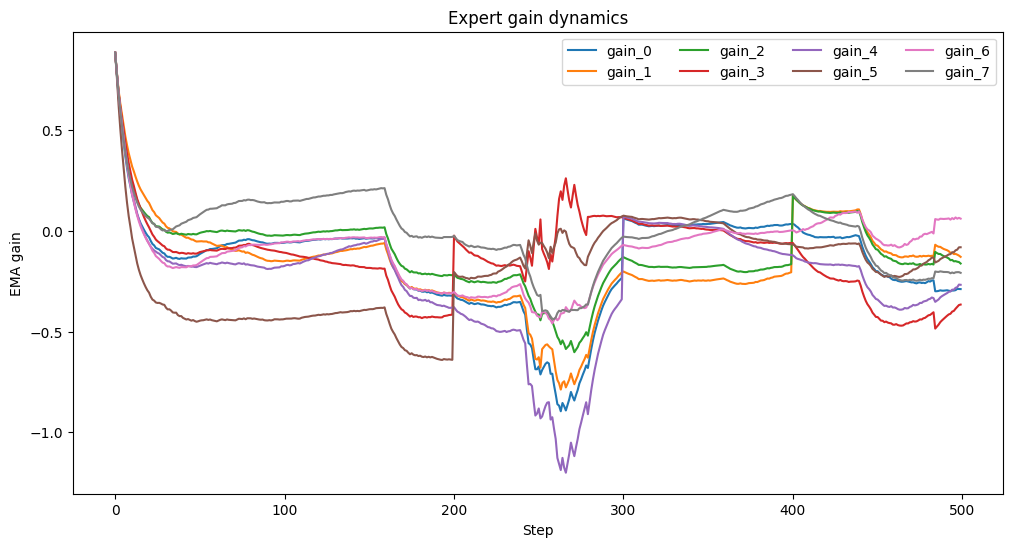

In [16]:
def plot_expert_gains(logs_df: pd.DataFrame):
    gain_cols = [f"gain_{i}" for i in range(CONFIG["num_experts"])]
    gain_frame = pd.DataFrame(logs_df["gain"].tolist(), columns=gain_cols)
    gain_frame["step"] = logs_df["step"]

    plt.figure(figsize=(12, 6))
    for col in gain_cols:
        plt.plot(gain_frame["step"], gain_frame[col], label=col)
    plt.xlabel("Step")
    plt.ylabel("EMA gain")
    plt.title("Expert gain dynamics")
    plt.legend(ncol=4)
    plt.show()

plot_expert_gains(logs_df)

# 17. Validation Loss Over Time

This cell shows whether online adaptation damages or improves different domains.

The key continual-learning question is not only:

> Does current-domain loss improve?

but also:

> Does earlier-domain loss degrade after the stream shifts?

This is the interference/forgetting measurement.

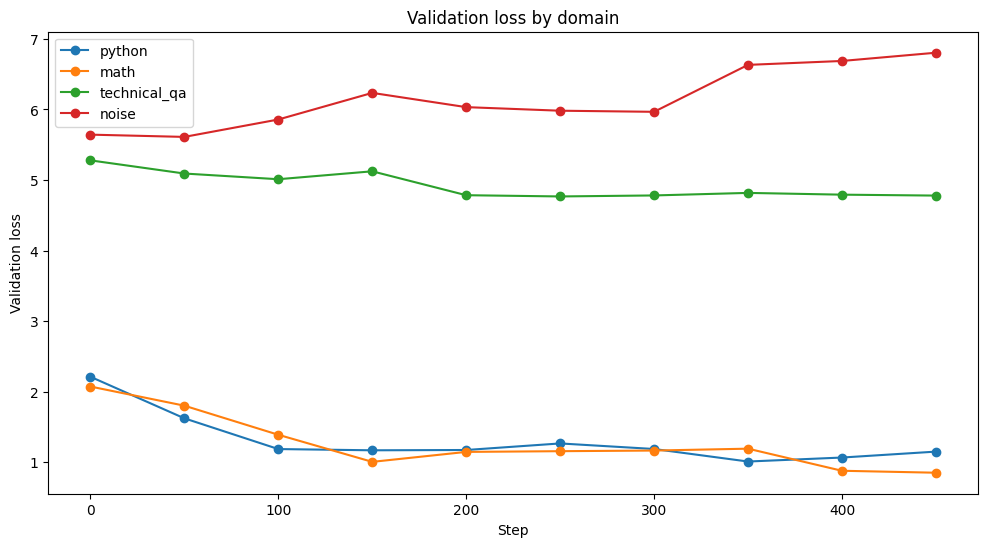

In [17]:
def plot_eval_losses(eval_df: pd.DataFrame):
    if eval_df.empty:
        print("No eval logs.")
        return
    plt.figure(figsize=(12, 6))
    for col in eval_df.columns:
        if col != "step":
            plt.plot(eval_df["step"], eval_df[col], marker="o", label=col)
    plt.xlabel("Step")
    plt.ylabel("Validation loss")
    plt.title("Validation loss by domain")
    plt.legend()
    plt.show()

plot_eval_losses(eval_df)

# 18. Expert Lifecycle Events

This cell inspects expert deaths and rebirths.

A healthy run should show occasional replacement of weak experts, especially during or after noisy data segments.

If no experts ever die, the GC threshold may be too conservative.  
If experts constantly die, the GC is too aggressive or the fitness signal is too noisy.

,step,type,dead_expert,parent_expert,new_gain
0,200,kill_clone_perturb,3,7,-0.023280
1,200,kill_clone_perturb,5,2,-0.204257
2,300,kill_clone_perturb,0,3,0.062091
3,300,kill_clone_perturb,4,5,0.071799
4,400,kill_clone_perturb,1,7,0.173203
5,400,kill_clone_perturb,2,7,0.173203


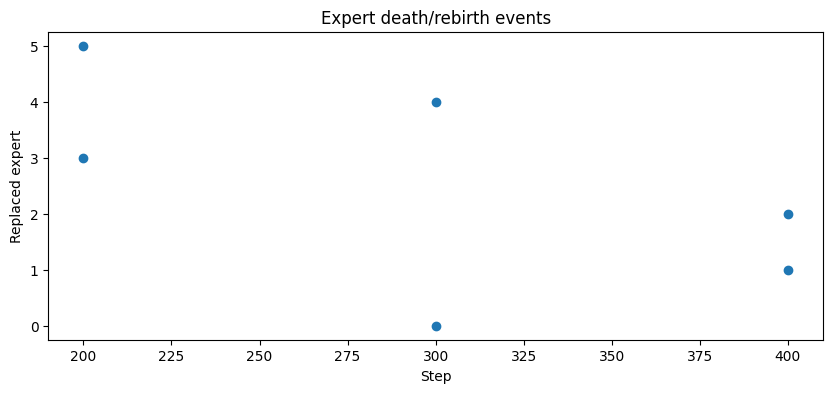

In [18]:
events_df = pd.DataFrame(expert_state.events)
if events_df.empty:
    print("No GC lifecycle events occurred.")
else:
    try:
        display(events_df)
    except NameError:
        print(events_df)
    plt.figure(figsize=(10, 4))
    plt.scatter(events_df["step"], events_df["dead_expert"])
    plt.xlabel("Step")
    plt.ylabel("Replaced expert")
    plt.title("Expert death/rebirth events")
    plt.show()

# 19. Runtime Flywheel API

This cell defines a persistent online API.

The system supports three modes:

## `inference_only`

Only a forward pass is performed.  
No learning, no gain update, no GC.

## `learn_from_input`

The input is treated as trusted online learning data.  
The model performs a training step and updates the expert population.

## `quarantine_input`

The input is stored but not learned immediately.  
This reflects a realistic deployment requirement: adaptive systems should not learn from every interaction.

The flywheel is therefore explicitly gated.

In [19]:
quarantine_buffer = []

@torch.no_grad()
def generate_text(prompt: str, max_new_tokens: int = 80) -> str:
    model.eval()
    batch = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **batch,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0], skip_special_tokens=True)

def adaptive_flywheel_step(user_text: str, mode: str = "inference_only", step: Optional[int] = None):
    # mode:
    #   - inference_only
    #   - learn_from_input
    #   - quarantine_input

    if mode == "inference_only":
        return {
            "mode": mode,
            "output": generate_text(user_text),
            "gain": expert_state.gain.detach().cpu().tolist(),
            "weights": expert_state.mixture_weights(CONFIG["hedge_eta"]).detach().cpu().tolist(),
        }

    if mode == "quarantine_input":
        quarantine_buffer.append(user_text)
        return {
            "mode": mode,
            "message": "Input stored in quarantine buffer. No learning performed.",
            "quarantine_size": len(quarantine_buffer),
        }

    if mode == "learn_from_input":
        if step is None:
            step = len(logs)
        log = train_one_step([user_text], step=step)
        return {
            "mode": mode,
            "training_log": log,
            "gain": expert_state.gain.detach().cpu().tolist(),
            "weights": expert_state.mixture_weights(CONFIG["hedge_eta"]).detach().cpu().tolist(),
        }

    raise ValueError(f"Unknown mode: {mode}")

# 20. Interactive Examples

Use these cells manually after training.

They demonstrate the three runtime modes without requiring an infinite notebook loop.

For a real persistent process, this API could be wrapped in a service loop.

In [20]:
# Example: inference only
# adaptive_flywheel_step("Explain LoRA in one paragraph.", mode="inference_only")

In [21]:
# Example: learn from trusted input
# adaptive_flywheel_step(
#     "Definition: GC-LoRA is a system where parallel LoRA experts compete using EMA fitness and weak experts are replaced by mutated clones.",
#     mode="learn_from_input",
#     step=CONFIG["train_steps"] + 1,
# )

In [22]:
# Example: quarantine untrusted input
# adaptive_flywheel_step("The derivative of x squared is definitely a cucumber.", mode="quarantine_input")

# 21. Baseline Plan

For a proper experimental comparison, the following baselines should be added in a second notebook or second run mode.

| Baseline | Purpose |
|---|---|
| Frozen Qwen only | Measures the base model without adaptation |
| Single LoRA adapter | Tests whether one online adapter drifts catastrophically |
| Static parallel LoRA without GC | Tests whether GC matters |
| Random replacement GC | Tests whether gain-based selection matters |
| GC-LoRA full system | Proposed method |

The present notebook implements the full GC-LoRA path first because the architectural mechanism must be validated before baseline automation is useful.

# 22. Limitations

This notebook is intentionally honest about what is not solved.

## Exact per-expert CE loss

Exact counterfactual per-expert loss would require separate forward passes or a more invasive architecture that exposes expert-specific logits in parallel.

This notebook instead uses gradient-alignment and local representation signals that are available from one simultaneous forward/backward pass.

## Synthetic data

The controlled data stream is designed for interpretability, not benchmark performance.

## No claim of general continual learning

If the run succeeds, it demonstrates a mechanism worth studying.  
It does not prove robust open-ended continual learning.

## Router-free design

The system uses gain-softmax rather than a learned router. This avoids router-expert feedback instability but reduces input-conditional routing expressivity.

A later version could introduce fast-weight or context-conditioned gain modulation.

# 23. Next Experiments

Recommended next steps:

1. Add the three baselines:
   - frozen-only,
   - single online LoRA,
   - static parallel LoRA without GC.

2. Replace synthetic data with small real domain streams:
   - Python snippets,
   - math derivations,
   - technical definitions,
   - adversarial/noisy examples.

3. Add context-conditioned gain modulation:
   - gain remains slow EMA,
   - input-conditioned fast weights modulate expert selection.

4. Test different injection sites:
   - `down_proj`,
   - `up_proj`,
   - `q_proj`,
   - `v_proj`.

5. Add quarantine batch review:
   - quarantined samples are periodically scored,
   - only trusted batches enter `learn_from_input`.

6. Add model-state checkpointing:
   - expert parameters,
   - gains,
   - lifecycle events,
   - quarantine buffer.